Building a Simple Arabic character Classifer using KNN.

Count classes

In [1]:
import os
dataset_path = "/content/drive/MyDrive/Arabic Handwritten Characters Dataset CSV"
classes = os.listdir(dataset_path)
print("Number of Classes:", len(classes))
print(classes[:10])

Number of Classes: 6
['csvTestImages 3360x1024.csv', 'csvTestLabel 3360x1.csv', 'csvTrainImages 13440x1024.csv', 'csvTrainLabel 13440x1.csv', 'test', 'Train Images 13440x32x32']


In [2]:
import cv2
import os
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import matplotlib.pyplot as plt

Read Dataset

In [3]:
dataset="/content/drive/MyDrive/Arabic Handwritten Characters Dataset CSV/"

images=[]
labels=[]

Load Dataset

In [4]:
import os
import cv2
import numpy as np
import re # Import the regular expression module

# Assuming 'dataset' is already defined as '/content/drive/MyDrive/Arabic Handwritten Characters Dataset CSV'
# and 'images', 'labels' are initialized as empty lists from T-pyAcPiMzJx

# Clear images and labels in case the cell is run multiple times
images = []
labels = []

# Iterate through the top-level items in the dataset directory
for item_name in os.listdir(dataset):
    item_path = os.path.join(dataset, item_name)

    # Only process directories (skip files like metadata.csv or processed_img1.png)
    if os.path.isdir(item_path):
        # Check if this directory contains subdirectories (like 'Consonents' containing 'क', 'ख')
        contains_subdirs = False
        for sub_item in os.listdir(item_path):
            if os.path.isdir(os.path.join(item_path, sub_item)):
                contains_subdirs = True
                break

        if contains_subdirs:
            # This is a category like 'Consonents', which has subfolders for each character
            for character_folder_name in os.listdir(item_path):
                character_folder_path = os.path.join(item_path, character_folder_name)
                if os.path.isdir(character_folder_path):
                    for img_file_name in os.listdir(character_folder_path):
                        img_file_path = os.path.join(character_folder_path, img_file_name)
                        # Check for common image file extensions
                        if os.path.isfile(img_file_path) and img_file_name.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
                            img = cv2.imread(img_file_path, 0) # Read as grayscale
                            if img is not None:
                                img = cv2.resize(img, (32, 32))
                                images.append(img.flatten())
                                # Extract the numeric label from the filename, e.g., '18' from 'id_XXXX_label_18.png'
                                match = re.search(r'label_(\d+)\.png$', img_file_name)
                                if match:
                                    labels.append(match.group(1)) # Append 'YY'
                                else:
                                    # Fallback if the pattern doesn't match, or skip the image if preferred
                                    # For now, let's append a placeholder for debugging
                                    labels.append('unknown_label')
        else:
            # This is a category like 'vowels' or 'numbers', where images are directly inside
            for img_file_name in os.listdir(item_path):
                img_file_path = os.path.join(item_path, img_file_name)
                # Check for common image file extensions
                if os.path.isfile(img_file_path) and img_file_name.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
                    img = cv2.imread(img_file_path, 0) # Read as grayscale
                    if img is not None:
                        img = cv2.resize(img, (32, 32))
                        images.append(img.flatten())
                        # Extract the numeric label from the filename, e.g., '18' from 'id_XXXX_label_18.png'
                        match = re.search(r'label_(\d+)\.png$', img_file_name)
                        if match:
                            labels.append(match.group(1)) # Append 'YY'
                        else:
                            # Fallback or error handling if pattern doesn't match
                            labels.append('unknown_label')


Convert into Numpy

In [5]:
X=np.array(images)
y=np.array(labels)

Split Dataset

In [6]:
import numpy as np

# Identify classes with only one member
unique_classes, counts = np.unique(y, return_counts=True)
classes_to_keep = unique_classes[counts > 1]

# Create a boolean mask to filter out samples belonging to classes with only one member
mask = np.isin(y, classes_to_keep)

# Apply the mask to X and y
X_filtered = X[mask]
y_filtered = y[mask]

X_train,X_test,y_train,y_test=train_test_split(
    X_filtered, # Use the filtered X
    y_filtered, # Use the filtered y
    test_size=0.2,
    random_state=42,
    stratify=y_filtered # Stratify with the filtered y
)

Dataset Path

In [7]:
train_path = "/content/drive/MyDrive/Arabic Handwritten Characters Dataset CSV/Train Images 13440x32x32"
test_path = "/content/drive/MyDrive/Arabic Handwritten Characters Dataset CSV/test"

Load Training Images

In [8]:
# The x_train and y_train variables are already correctly defined from the train_test_split
# in cell PGELgAK8ERoo. This cell's content was causing a mismatch by redefining y_train
# with a different size and incorrect labels. Hence, its content is now commented out.

# x_train = []
# y_train = []

# for class_name in os.listdir(train_path):
#     class_path = os.path.join(train_path, class_name)
#     if os.path.isdir(class_path):
#         for img_name in os.listdir(class_path):
#             img_path = os.path.join(class_path, img_name)
#             img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
#             if img is not None:
#                 img = cv2.resize(img, (32, 32))
#                 x_train.append(img.flatten())
#                 y_train.append(class_name)
# x_train = np.array(x_train)
# y_train = np.array(y_train)
print("Training data shape:", X_train.shape)
print("Training labels shape:", y_train.shape)

Training data shape: (13465, 1024)
Training labels shape: (13465,)


Load Test Images

In [9]:
import re # Import the regular expression module for label extraction

x_test = []
y_test = []

# Iterate directly through files in the test_path
for img_name in os.listdir(test_path):
    img_path = os.path.join(test_path, img_name)
    # Check if it's a file and has an image extension
    if os.path.isfile(img_path) and img_name.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            img = cv2.resize(img, (32, 32))
            x_test.append(img.flatten())
            # Extract the numeric label from the filename, e.g., '18' from 'id_XXXX_label_18.png'
            match = re.search(r'label_(\d+)\.png$', img_name)
            if match:
                y_test.append(match.group(1)) # Append the extracted label
            else:
                # Fallback if the pattern doesn't match, or skip the image if preferred
                y_test.append('unknown_label') # Assign 'unknown_label' or handle as needed

x_test = np.array(x_test)
y_test = np.array(y_test)

print("Test data shape:", x_test.shape)
print("Test labels shape:", y_test.shape)

Test data shape: (3360, 1024)
Test labels shape: (3360,)


Let's inspect the contents of the `test_path` directory to understand why no files were loaded.

In [10]:
print(f"Contents of {test_path}:")

if os.path.exists(test_path):
    if os.path.isdir(test_path):
        contents = os.listdir(test_path)
        if contents:
            for item in contents:
                item_path = os.path.join(test_path, item)
                if os.path.isdir(item_path):
                    print(f"  - Directory: {item} (contains {len(os.listdir(item_path))} items)")
                else:
                    print(f"  - File: {item}")
        else:
            print("  (Directory is empty)")
    else:
        print(f"  (Error: {test_path} is not a directory)")
else:
    print(f"  (Error: {test_path} does not exist)")

Contents of /content/drive/MyDrive/Arabic Handwritten Characters Dataset CSV/test:
  - File: id_3116_label_18.png
  - File: id_3098_label_9.png
  - File: id_3120_label_20.png
  - File: id_3144_label_4.png
  - File: id_3148_label_6.png
  - File: id_3139_label_2.png
  - File: id_3090_label_5.png
  - File: id_3143_label_4.png
  - File: id_3119_label_20.png
  - File: id_3147_label_6.png
  - File: id_3121_label_21.png
  - File: id_3093_label_7.png
  - File: id_3135_label_28.png
  - File: id_3079_label_28.png
  - File: id_3095_label_8.png
  - File: id_308_label_14.png
  - File: id_3094_label_7.png
  - File: id_3133_label_27.png
  - File: id_3115_label_18.png
  - File: id_3110_label_15.png
  - File: id_3145_label_5.png
  - File: id_3136_label_28.png
  - File: id_3118_label_19.png
  - File: id_3101_label_11.png
  - File: id_3131_label_26.png
  - File: id_3126_label_23.png
  - File: id_3088_label_4.png
  - File: id_3141_label_3.png
  - File: id_3111_label_16.png
  - File: id_3113_label_17.png
 

## Number of Images per Label in Test Set

In [11]:
unique_labels, label_counts = np.unique(y_test, return_counts=True)

print("Number of images per label in y_test:")
for label, count in zip(unique_labels, label_counts):
    print(f"Label {label}: {count} images")

Number of images per label in y_test:
Label 1: 120 images
Label 10: 120 images
Label 11: 120 images
Label 12: 120 images
Label 13: 120 images
Label 14: 120 images
Label 15: 120 images
Label 16: 120 images
Label 17: 120 images
Label 18: 120 images
Label 19: 120 images
Label 2: 120 images
Label 20: 120 images
Label 21: 120 images
Label 22: 120 images
Label 23: 120 images
Label 24: 120 images
Label 25: 120 images
Label 26: 120 images
Label 27: 120 images
Label 28: 120 images
Label 3: 120 images
Label 4: 120 images
Label 5: 120 images
Label 6: 120 images
Label 7: 120 images
Label 8: 120 images
Label 9: 120 images


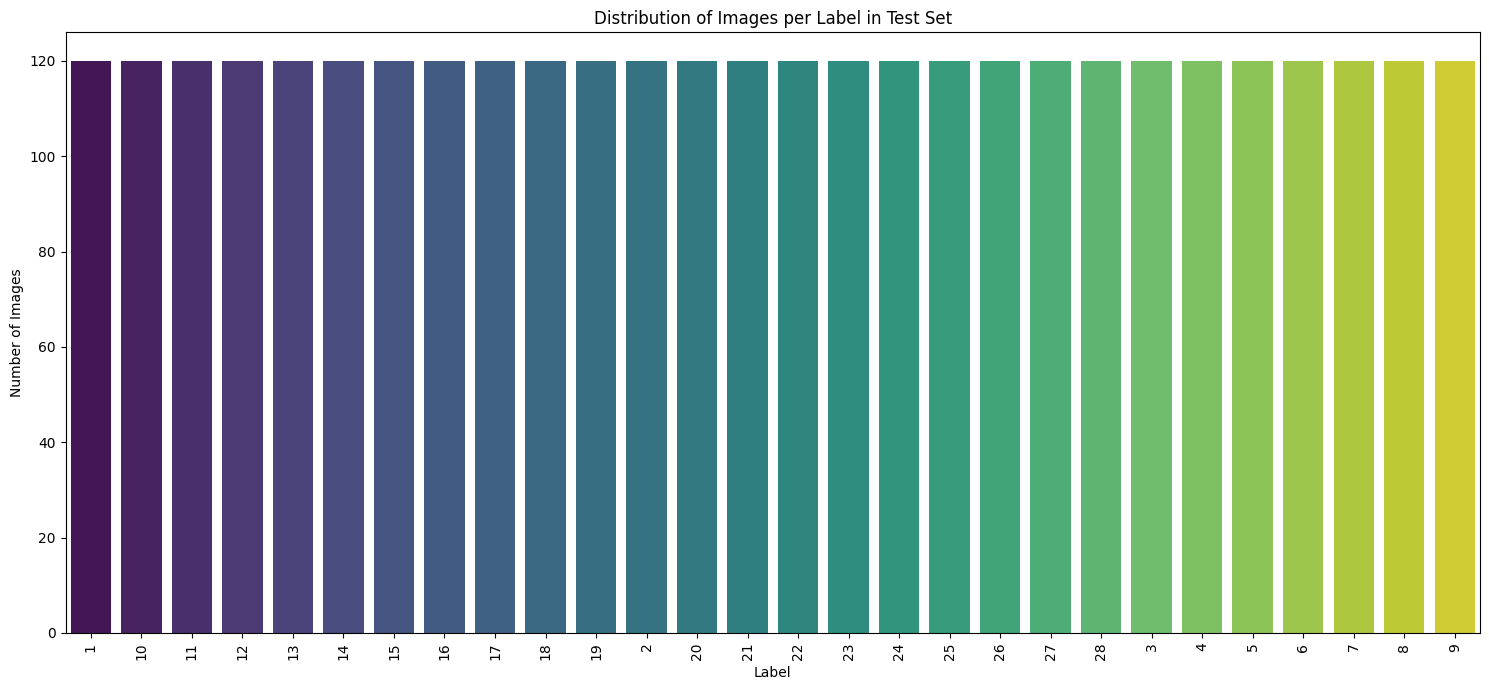

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 7))
sns.barplot(x=unique_labels, y=label_counts, hue=unique_labels, palette='viridis', legend=False)
plt.xlabel('Label')
plt.ylabel('Number of Images')
plt.title('Distribution of Images per Label in Test Set')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

This bar chart clearly shows that the test dataset is balanced, with each of the 28 unique labels containing 120 images. This is a good characteristic for training and evaluating classification models, as it prevents bias towards majority classes.

Train KNN Model

In [30]:
knn_model = KNeighborsClassifier(n_neighbors=3) # You can adjust n_neighbors
knn_model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [31]:
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")

Shape of X_train: (13465, 1024)
Shape of y_train: (13465,)


Prediction

In [33]:
y_pred = knn_model.predict(x_test)

Accuracy

In [34]:
print("Shape of y_test:", y_test.shape)
print("Shape of X_test:", x_test.shape)

Shape of y_test: (3360,)
Shape of X_test: (3360, 1024)


In [35]:
y_pred = knn_model.predict(x_test)
print("Shape of y_pred:", y_pred.shape)

Shape of y_pred: (3360,)


In [36]:
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)

Accuracy: 0.7494047619047619


Confusion Matrix

In [37]:
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[120   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0 114   5   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   1   0]
 [  2  47  68   0   0   0   0   0   0   0   0   0   0   0   0   0   1   0
    0   0   0   0   0   0   0   0   1   1]
 [  0   3   0 106   0   6   0   0   0   0   0   2   0   0   0   0   0   1
    1   0   0   0   1   0   0   0   0   0]
 [  0   1   2  33  78   2   0   0   0   0   0   1   1   1   0   0   0   0
    1   0   0   0   0   0   0   0   0   0]
 [  0   0   0  17   1 100   0   0   0   0   0   1   0   0   0   0   0   0
    1   0   0   0   0   0   0   0   0   0]
 [  0   2   0  20   2  22  70   0   0   0   0   0   3   0   0   0   0   0
    0   1   0   0   0   0   0   0   0   0]
 [  1   3   0   0   0   0   0 108   2   0   0   0   0   0   0   1   0   0
    1   1   0   0   0   0   0   0   1   2]
 [  0   2   0   0   0   1   0  38  74   0   0   1   0   0   0   

Classification Report

In [41]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           1       0.88      1.00      0.94       120
          10       0.52      0.95      0.67       120
          11       0.76      0.57      0.65       120
          12       0.54      0.88      0.67       120
          13       0.90      0.65      0.75       120
          14       0.70      0.83      0.76       120
          15       0.89      0.58      0.70       120
          16       0.66      0.90      0.76       120
          17       0.86      0.62      0.72       120
          18       0.56      0.88      0.68       120
          19       0.78      0.61      0.68       120
           2       0.69      0.95      0.80       120
          20       0.61      0.69      0.65       120
          21       0.78      0.65      0.71       120
          22       0.99      0.84      0.91       120
          23       0.88      0.89      0.89       120
          24       0.94      0.97      0.95       120
          25       0.86    